# Systemy uczące się - Zad. dom. 4: Ocena modeli predykcyjnych

### Autor rozwiązania
Uzupełnij poniższe informacje umieszczając swoje imię i nazwisko oraz numer indeksu:

In [4]:
NAME = "Jakub Bilski"
ID = "155865"

Ten notebook zawiera zadania związane z oceną modeli predykcyjnych. Oprócz zadań programistycznych, notebook zawira również pytania, na które trzeba odpowiedzieć. Odpowiedzi nie muszą być długie, ale powinny być merytoryczne i odnosić się do omawianych zagadnień. W tym zadaniu domowym należy odpowiedzieć na WSZYSTKIE pytania.


## Format danych
W tym zadaniu domyślnym typem danych będą macierze (`np.ndarray`) o rozmiarze `(n, c)`, gdzie `n` to liczba obserwacji, a `c` to liczba klas. Wartości w macierzy będą reprezentować:

- w przypadku `y` - prawdziwe klasy (wartości binarne). Na przykład:
    ```
    [
        [1, 0, 0],
        [0, 0, 1],
        [1, 0, 0],
    ]
    ```
    oznacza, że pierwsza i trzecia obserwacja należą do klasy 0, a druga do klasy 2.

- w przypadku `y_hat` - predykcje modelu. Wartości w macierzy mogą reprezentować:
    * prawdopodobieństwa przynależności do danej klasy (wartości z przedziału `[0, 1]`). Na przykład:
        ```
        [
            [0.9, 0.1, 0.0],
            [0.1, 0.2, 0.7],
            [0.8, 0.2, 0.0],
        ]
        ```
        oznacza, że model przewiduje, że pierwsza obserwacja należy do klasy 0 z prawdopodobieństwem 0.9, a do klasy 1 z prawdopodobieństwem 0.1.
    
    * predykcje (wartości binarne), gdzie wartość `1` oznacza przynależność do danej klasy, a wartość `0` jej brak.
        ```
        [
            [0, 1, 0],
            [0, 0, 1],
            [0, 1, 0],
        ]
        ```
        oznacza, że model przewiduje, że pierwsza obserwacja należy do klasy 1, a druga do klasy 2.

# Zadanie 1: Punktowe miary oceny klasyfikatorów

Zadanie polega na zaimplementowaniu funkcji obliczających punktowe miary oceny klasyfikatorów, takich jak:
- dokładność (accuracy),
- precyzja (precision),
- czułość (recall),
- specyficzność (specificity),
- F1,
- G-mean,
- balanced accuracy.

Uwagi:
- Do rozwiązania zadania można wykorzystać wyłącznie bibliotekę `numpy`.
- Na potrzeby zadania domowego można założyć, że klasyfikacja jest wieloklasowa, ale jednoetykietowa (tj. każda obserwacja należy do dokładnie jednej klasy).
- W przypadku, gdy mianownik w równaniu miary oceny jest równy 0, wartość miary powinna wynosić 0.
- Podpowiedź: przy obliczaniu wielu miar warto zaimplementować funkcję pomocniczą, która oblicza macierz pomyłek.

In [5]:
from typing import Literal

import numpy as np

In [6]:
y = np.eye(2, dtype=int)[np.repeat([0, 1], 50)]
y_hat_0 = np.tile([1, 0], (100, 1))
y_hat_1 = np.tile([0, 1], (100, 1))

In [7]:
def accuracy(y_hat: np.ndarray, y: np.ndarray) -> float:
    """Funkcja obliczająca dokładność klasyfikacji (accuracy). Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.

    Returns:
        float: Dokładność klasyfikacji.
    """
    predicted_classes = np.argmax(y_hat, axis=1)
    true_classes = np.argmax(y, axis=1)
    correct = np.sum(predicted_classes == true_classes)
    return float(correct/len(y))
    ...

In [8]:
def precision(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca precyzję klasyfikacji (precision). Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".

    Returns:
        float: Precyzja klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)

    num_classes = y.shape[1]

    tp = np.zeros(num_classes)
    fp = np.zeros(num_classes)

    for i in range(num_classes):
      tp[i] = np.sum((predicted == i) & (true == i))
      fp[i] = np.sum((predicted == i) & (true != i))

    if average == "micro":
      return float(np.sum(tp) / (np.sum(tp) + np.sum(fp)))
    elif average == "macro":
      per_class = np.where (tp + fp > 0, tp / (tp + fp), 0.0)
      return float(np.mean(per_class))

    ...

In [9]:
def recall(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca czułość klasyfikacji (recall). Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".

    Returns:
        float: Precyzja klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)

    num_classes = y.shape[1]

    tp = np.zeros(num_classes)
    fn = np.zeros(num_classes)

    for i in range(num_classes):
      tp[i] = np.sum((predicted == i) & (true == i))
      fn[i] = np.sum((predicted != i) & (true == i))

    if average == "micro":
      return float(np.sum(tp) / (np.sum(tp) + np.sum(fn)))
    elif average == "macro":
      per_class = np.where (tp + fn > 0, tp / (tp + fn), 0.0)
      return float(np.mean(per_class))
    ...

In [10]:
def specificity(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca specyficzność klasyfikacji (specificity). Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".

    Returns:
        float: Specyficzność klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)

    num_classes = y.shape[1]
    tn = np.zeros(num_classes)
    fp = np.zeros(num_classes)

    for i in range(num_classes):
      tn[i] = np.sum((predicted == i) & (true == i))
      fp[i] = np.sum((predicted == i) & (true != i))

    if average == "micro":
      return float(np.sum(tn) / (np.sum(tn) + np.sum(fp)))
    elif average == "macro":
      per_class = np.where(tn + fp > 0, tn / (tn +fp), 0.0)
      return float(np.mean(per_class))
    ...

Zatrzymaj się w tym miejscu na chwilę i poeksperymentuj z dotychczas zaimplementowanymi funkcjami i danymi testowymi. Spróbuj zrozumieć, jak działają poszczególne miary oceny klasyfikatorów. Możesz ograniczyć się do uśredniania wyników "micro".

In [11]:
y = np.eye(2, dtype=int)[np.repeat([0, 1], [90, 10])]
y_hat_0 = np.tile([1, 0], (100, 1))  # zawsze klasa 0
y_hat_1 = np.tile([0, 1], (100, 1))  # zawsze klasa 1

print(f"{'Model':<20} {'Avg':<8} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'Spec':>6}")
for name, y_hat in [("zawsze klasa 0", y_hat_0), ("zawsze klasa 1", y_hat_1)]:
    acc = accuracy(y_hat, y)
    for avg in ["micro", "macro"]:
        prec = precision(y_hat, y, avg)
        rec  = recall(y_hat, y, avg)
        spec = specificity(y_hat, y, avg)
        label = name if avg == "micro" else ""
        print(f"{label:<20} {avg:<8} {acc:>6.3f} {prec:>6.3f} {rec:>6.3f} {spec:>6.3f}")
    print()

Model                Avg         Acc   Prec    Rec   Spec
zawsze klasa 0       micro     0.900  0.900  0.900  0.900
                     macro     0.900  0.450  0.500  0.450

zawsze klasa 1       micro     0.100  0.100  0.100  0.100
                     macro     0.100  0.050  0.500  0.050



/tmp/ipykernel_4710/2495083899.py:27: RuntimeWarning: invalid value encountered in divide
  per_class = np.where (tp + fp > 0, tp / (tp + fp), 0.0)
/tmp/ipykernel_4710/422586221.py:26: RuntimeWarning: invalid value encountered in divide
  per_class = np.where(tn + fp > 0, tn / (tn +fp), 0.0)


Odpowiedz na pytanie

1. Czy zaimplementowane funkcje mogą być wystarczające do oceny modeli klasyfikacyjnych? Jeśli nie, to dlaczego? Jeśli tak, to w jakich przypadkach?

Model może mieć wysoki recall kosztem precision, więc warto spróbować użyć dodatkowe metryki, np F1-score - w szczególności, gdy mamy np. do czynienia z niezbalansowanymi danymi. Acc, recall, spec i prec nie biorą także pod uwagę prawdopodobieństwa przydziału do danej klasy, a tylko "suche" predykcje końcowe. Powyższe funkcje wystarczają, gdy mamy zbalansowane klasy i nie zależnym nam na szczególnej analizie oceny dla poszczególnych klas, a stawiamy raczej po prostu na accuracy.

In [12]:
def f1(y_hat: np.ndarray, y: np.ndarray, average: Literal["micro", "macro"] = "micro") -> float:
    """Funkcja obliczająca miarę F1. Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.
        average ("micro" | "macro"): Typ uśredniania wyników. Domyślnie "micro".

    Returns:
        float: Specyficzność klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)
    num_classes = y.shape[1]

    tp = np.zeros(num_classes)
    fp = np.zeros(num_classes)
    fn = np.zeros(num_classes)

    for i in range(num_classes):
      tp[i] = np.sum((predicted == i) & (true == i))
      fp[i] = np.sum((predicted == i) & (true != i))
      fn[i] = np.sum((predicted != i) & (true == i))

    if average == "micro":
      tp_sum = np.sum(tp)
      fp_sum = np.sum(fp)
      fn_sum = np.sum(fn)
      return float(2*tp_sum / (2*tp_sum + fp_sum + fn_sum))
    elif average == "macro":
      per_class = np.where(2*tp + fn + fn > 0, 2*tp / (2*tp + fp + fn), 0.0)
      return float(np.mean(per_class))

    ...

In [13]:
def g_mean(y_hat: np.ndarray, y: np.ndarray) -> float:
    """Funkcja obliczająca miarę G-mean. Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.

    Returns:
        float: Specyficzność klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)

    num_classes = y.shape[1]
    tp = np.zeros(num_classes)
    fn = np.zeros(num_classes)

    for i in range(num_classes):
      tp[i] = np.sum((predicted == i) & (true == i))
      fn[i] = np.sum((predicted != i) & (true == i))

    recall_per_class = np.where(tp + fn > 0, tp / (tp + fn), 0.0)

    return float(np.prod(recall_per_class)**(1/num_classes))

    ...

In [14]:
def balanced_accuracy(y_hat: np.ndarray, y: np.ndarray) -> float:
    """Funkcja obliczająca zbalansowaną dokładność klasyfikacji. Funkcja powinna wspierać klasyfikację wieloklasową.

    Args:
        y_hat (np.ndarray): Macierz z predykacjami modelu o wymiarach `(n, c)`.
        y (np.ndarray): Macierz z prawdziwymi klasami o wymiarach `(n, c)`.

    Returns:
        float: Zbalansowana dokładność klasyfikacji.
    """
    predicted = np.argmax(y_hat, axis=1)
    true = np.argmax(y, axis=1)

    num_classes = y.shape[1]

    tp = np.zeros(num_classes)
    fn = np.zeros(num_classes)

    for i in range(num_classes):
      tp[i] = np.sum((predicted == i) & (true == i))
      fn[i] = np.sum((predicted != i) & (true == i))

    recall_per_class = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
    return float(np.mean(recall_per_class))
    ...

Sprawdź jak zaimplementowane funkcje działają na 3 zbiorach testowych o różnej charakterystyce.

### Scenariusz 1

In [15]:
# dane silnie niezbalansowane: 80% klasa 0, 10% klasa 1, 5% klasa 2, 5% klasa 3
y = np.eye(4)[np.array([0] * 80 + [1] * 10 + [2] * 5 + [3] * 5)]

# model przewiduje zawsze klasę 0
y_hat_all_0 = np.eye(4)[np.array([0] * 100)]

# model poprawnie przewiduje klasy 0 i 1, ale zawsze myli klasy 2 i 3
y_hat_partial = np.eye(4)[np.array([0] * 80 + [1] * 10 + [3] * 5 + [2] * 5)]

In [16]:
print(f"{'Model':<20} {'Acc':>6} {'F1m':>6} {'F1M':>6} {'BAcc':>6} {'Gmean':>6}")
for name, y_hat in [("all_0", y_hat_all_0), ("partial", y_hat_partial)]:
    print(f"{name:<20} "
          f"{accuracy(y_hat, y):>6.3f} "
          f"{f1(y_hat, y, 'micro'):>6.3f} "
          f"{f1(y_hat, y, 'macro'):>6.3f} "
          f"{balanced_accuracy(y_hat, y):>6.3f} "
          f"{g_mean(y_hat, y):>6.3f}")

Model                   Acc    F1m    F1M   BAcc  Gmean
all_0                 0.800  0.800  0.222  0.250  0.000
partial               0.900  0.900  0.500  0.500  0.000


### Scenariusz 2

In [17]:
# dane niezbalansowane: 50 próbek klasy 0, 25 klasy 1, 15 klasy 2, 10 klasy 3
y = np.eye(4)[np.array([0] * 50 + [1] * 25 + [2] * 15 + [3] * 10)]

# Model przewiduje 60 próbek jako klasa 0, reszta losowo
np.random.seed(42)
y_hat = np.eye(4)[np.array([0] * 60 + list(np.random.choice([1, 2, 3], size=40)))]

In [18]:
print("Scenariusz 2:")
print(f"  accuracy:          {accuracy(y_hat, y):.3f}")
print(f"  f1 micro:          {f1(y_hat, y, 'micro'):.3f}")
print(f"  f1 macro:          {f1(y_hat, y, 'macro'):.3f}")
print(f"  balanced_accuracy: {balanced_accuracy(y_hat, y):.3f}")
print(f"  g_mean:            {g_mean(y_hat, y):.3f}")

Scenariusz 2:
  accuracy:          0.650
  f1 micro:          0.650
  f1 macro:          0.487
  balanced_accuracy: 0.515
  g_mean:            0.423


### Scenariusz 3

In [19]:
# dane niezbalansowane jak w Scenariuszu 2
y = np.eye(4)[np.array([0] * 50 + [1] * 25 + [2] * 15 + [3] * 10)]

# model losowy
np.random.seed(0)
y_hat = np.eye(4)[np.random.choice([0, 1, 2, 3], size=100)]

In [20]:
print("\nScenariusz 3:")
print(f"  accuracy:          {accuracy(y_hat, y):.3f}")
print(f"  f1 micro:          {f1(y_hat, y, 'micro'):.3f}")
print(f"  f1 macro:          {f1(y_hat, y, 'macro'):.3f}")
print(f"  balanced_accuracy: {balanced_accuracy(y_hat, y):.3f}")
print(f"  g_mean:            {g_mean(y_hat, y):.3f}")


Scenariusz 3:
  accuracy:          0.240
  f1 micro:          0.240
  f1 macro:          0.223
  balanced_accuracy: 0.260
  g_mean:            0.249


### Pytania

Odpowiedz na pytania:
1. Jakie różnice daje uśrednianie wyników "micro" w porównaniu do "macro"? Dla jakich danych warto użyć jednego, a dla jakich drugiego sposobu uśredniania wyników?

Micro sumuje TP/FP/FN globalnie po wszystkich klasach, przez co dominującą rolę odgrywają klasy większościowe. Przy zbalansowanych danych micro jest bardzo bliskie accuracy, więc nie dowiadujemy się nic nowego nt. naszego treningu. W przypadku macro, liczymy oceny modeli dla każddej klasy osobno i uśredniami je. Micro - sensowne, gdy klasy zbalansowane. Macro - wręcz wskazane przy niezbalansownanych danych.

2. Dlaczego warto stosować zbalansowaną dokładność (balanced accuracy) zamiast zwykłej dokładności (accuracy)?

Zwykłe accuracy może zwrócić nam niezbyt przydatną informację dla niezbalansowanych klas - będzie przewidywać przede wszystkim klasę dominująacą. Balanced accuracy uśrednia recall dla każdej klasy, czyli model musi działać dobrze na każdej klasie, nie tylko dominującej, aby uzyskać dobrą ocenę. Widać to dobrze przy scenariuszu 1, gdzie przy bardzo mocno niezbalansowanych danych mamy dość wysokie accuracy (0.8), ale bardzo niskie balanced accuracy (0.25).

3. Dlaczego warto stosować miarę G-mean zamiast F1? Dla jakich scenariuszy miara G-mean pozwala na bardziej adekwatną ocenę modelu?

Gdy spojrzymy do wzoru na F1 (średnia harmoniczna precyzji i czułości), to widzimy, że nie bierze on pod uwagę TN, czyli koncentruje się na tym, jak model klasyfikuje klasy pozytywne. Ponieważ G-mean jest średnią geometryczną czułości i specificity, bierze on pod uwagę umiejętność modelu do rozpoznawania klas negatywnych. Jeśli model sklasyfikuje wszystko jako klasę pozytywną, czyli zerowe specificity, to G-mean wynosi zero.


[TODO: Twoje odpowiedzi]

# Zadanie 2: k-folds cross-validation

Zaimplementuj funkcję `split_to_k_folds`, która dokona podziału danych na `k` zbiorów treningowych i testowych. Następnie dokonaj analizy wpływu stratyfikacji na postrzegane ryzyko modelu.

In [28]:
def split_to_k_folds(x: np.ndarray, y: np.ndarray, k: int = 5, stratify: bool = True
                     ) -> list[tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]]:
    """Funkcja implementująca k-krotną walidację krzyżową.

    W przypadku stratyfikacji, funkcja powinna zachować proporcje klas w podziałach. W tym celu można
    wykorzystać prosty algorytm zaproponowany podczas laboratorium.

    Funkcja powinna zwracać listę krotek, gdzie każda krotka zawiera dane podzielone na zbiór treningowy i testowy.
    Rozwiązanie to w oczywisty sposób nie jest optymalne pod względem pamięciowym, ale taki format zwracania danych
    pomoże w dalszej części zadania.

    Args:
        x (np.ndarray): Macierz z danymi o wymiarach `(n, d)`.
        y (np.ndarray): Macierz z etykietami o wymiarach `(n, c)`.
        k (int): Liczba podziałów zbioru danych. Domyślnie 5.
        stratify (bool): Czy zachować proporcje klas w podziałach. Domyślnie `True`.

    Returns:
        list[tuple[np.ndarray]]: Lista krotek z podziałami danych na zbiór treningowy i testowy.
    """
    n = len(x)
    result = []

    if stratify:
      classes = np.unique(y)
      class_folds = []
      for i in classes:
        idx = np.where(y == i)[0]
        np.random.shuffle(idx)
        class_folds.append(np.array_split(idx, k))

      folds = [np.concatenate([class_folds[i][j] for i in range(len(classes))]) for j in range(k)]

    else:
      idx = np.arange(n)
      np.random.shuffle(idx)
      folds = np.array_split(idx, k)

    for i in range(k):
      test_idx = folds[i]
      train_idx = np.concatenate([folds[j] for j in range(k) if j != i])

      x_train, y_train = x[train_idx], y[train_idx]
      x_test, y_test = x[test_idx], y[test_idx]

      result.append(((x_train, y_train), (x_test, y_test)))

    return result

    ...

Przykładowe dane testowe. Zwróć uwagę, że dane te są niezbalansowane. Możesz dokonać modyfikacji danych, aby zobaczyć, jak zachowuje się algorytm w zależności od charakterystyki danych.

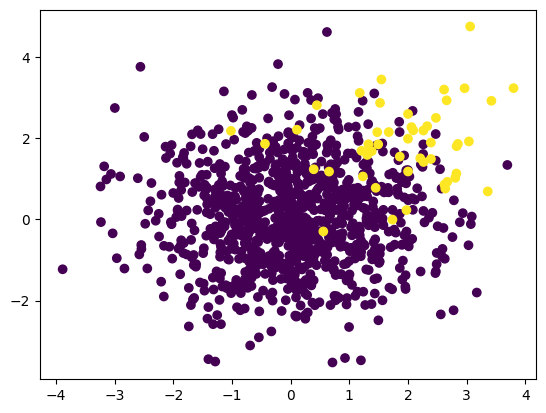

In [26]:
import matplotlib.pyplot as plt

n0 = 1000
n1 = 50

np.random.seed(42)
x1 = np.random.randn(n0, 2) * 1.2
x2 = np.random.randn(n1, 2) + [2, 2]

x = np.vstack([x1, x2])
y = np.array([0] * n0 + [1] * n1)

plt.scatter(x[:, 0], x[:, 1], c=y)
plt.show()

In [29]:
splits_stratified = split_to_k_folds(x, y, k=5, stratify=True)
splits = split_to_k_folds(x, y, k=5, stratify=False)

print("Stratified:")
for i, ((x_train, y_train), (x_test, y_test)) in enumerate(splits_stratified):
    ratio = np.mean(y_test == 1)
    print(f"  Fold {i}: test size={len(y_test)}, klasa 1 w teście: {np.sum(y_test==1)} ({ratio:.2%})")

print("\nNie-stratified:")
for i, ((x_train, y_train), (x_test, y_test)) in enumerate(splits):
    ratio = np.mean(y_test == 1)
    print(f"  Fold {i}: test size={len(y_test)}, klasa 1 w teście: {np.sum(y_test==1)} ({ratio:.2%})")

Stratified:
  Fold 0: test size=210, klasa 1 w teście: 10 (4.76%)
  Fold 1: test size=210, klasa 1 w teście: 10 (4.76%)
  Fold 2: test size=210, klasa 1 w teście: 10 (4.76%)
  Fold 3: test size=210, klasa 1 w teście: 10 (4.76%)
  Fold 4: test size=210, klasa 1 w teście: 10 (4.76%)

Nie-stratified:
  Fold 0: test size=210, klasa 1 w teście: 5 (2.38%)
  Fold 1: test size=210, klasa 1 w teście: 15 (7.14%)
  Fold 2: test size=210, klasa 1 w teście: 10 (4.76%)
  Fold 3: test size=210, klasa 1 w teście: 7 (3.33%)
  Fold 4: test size=210, klasa 1 w teście: 13 (6.19%)


Przeprowadź walidację krzyżową dla klasyfikatora `GaussianNB` na danych z poprzedniego kroku. Porównaj wyniki dla obu wariantów podziału danych. Na podstawie obserwacji z poprzedniego zadania, wybierz miary oceny klasyfikatora, które uznasz za najbardziej adekwatne do tego zadania.

Poniższą komórkę możesz dowolnie modyfikować, aby np. obliczać kilka miar jednocześnie.

In [43]:
from sklearn.naive_bayes import GaussianNB

metrics = []

for (x_train, y_train), (x_test, y_test) in splits:
    model = GaussianNB()
    model.fit(x_train, y_train)
    y_hat = model.predict(x_test)
    num_classes = len(np.unique(y_train))
    y_hat_oh = np.eye(num_classes, dtype=int)[y_hat]
    y_test_oh = np.eye(num_classes, dtype=int)[y_test]
    metrics.append([
        balanced_accuracy(y_hat_oh, y_test_oh),
        g_mean(y_hat_oh, y_test_oh),
        f1(y_hat_oh, y_test_oh, "macro"),
    ])

metrics = np.array(metrics)  # (5, 3)
names = ["balanced_acc", "g_mean", "f1_macro"]
for i, name in enumerate(names):
    print(f"{name:<15}: {np.mean(metrics[:, i]):.4f} +/- {np.std(metrics[:, i]):.4f}")

balanced_acc   : 0.7172 +/- 0.0929
g_mean         : 0.6471 +/- 0.1406
f1_macro       : 0.7471 +/- 0.0698


### Pytania

Odpowiedz na pytania:
1. Jaka była Twoja motywacja do wybrania konkretnych miar klasyfikacji?
2. Dla jakich danych warto zastosować stratyfikację podczas walidacji krzyżowej?
3. Jakie ryzyko niesie za sobą losowy podział danych na dwa zbiory (treningowy i testowy), zamiast używania walidacji krzyżowej ze stratyfikacją?

Odpowiedzi:

1. Ponieważ dane są bardzo mocno niezbalansowane (stosunek ok. 95:5), zastosowanie zwykłego accuracy byłoby mylące - co z tego, że model zazwyczaj przewidywałby cały czas klasę większościową, osiągając przy tym acc na poziomie 95% i więcej, skoro ignorowałby klasę mniejszościową. Balanced Accuracy sygnalizuje, jak model sprawuje się na wszystkich klasach, niezależnie od tego, jaką część zbioru zajmują. To pozwala uzyskać obiektywne i rzetelen oceny modelu.

2. Stratyfikacja jest wręcz wskazana dla danych z niezbalansowanymi klasami i małych zbiorów danych. Dzięki temu zabiegowi, zachowujemy proporcje klas z pierwotnego, pełnego zbioru. Bez wykonania takiej operacji może dojść do sytuacji, gdzie jakiś fold będzie pozbawiony przykładów z danej klasy.

3. Przy małych zbiorach to marnowanie danych - odłożenie np. 10-20% danych do zbioru testowego może bardzo negatywnie wpłynąć na jakość modelu. Walidacja krzyżowa używa wszystkie dane w procesie uczenia, przez co dane się nie marnują. Bez stratyfikacji, klasa mniejszościowa może w całości lub w większości wylądować w zbiorze treningowym lub testowym. Przy losowym podziale danych, wynik ewaluacji jest uzależniony od szczęścia - jeśli trafimy w zestaw przykładów, który dobrze działa na wytrenowanym modelu, to osiągniemy optymistyczny, wysoki wynik. To samo w drugą stronę, gdy wylosujemy gorszy zbiór - wtedy wyniki są gorsze.